In [9]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl


In [10]:
data = pd.read_csv("cost_revenue_clean.csv")
data.describe()


,production_budget_usd,worldwide_gross_usd
count,5.034000e+03,5.034000e+03
mean,3.290784e+07,9.515685e+07
std,4.112589e+07,1.726012e+08
min,1.100000e+03,2.600000e+01
25%,6.000000e+06,7.000000e+06
50%,1.900000e+07,3.296202e+07
75%,4.200000e+07,1.034471e+08
max,4.250000e+08,2.783919e+09


In [11]:
x = pd.DataFrame(data, columns=['production_budget_usd'])       # Production Budget 
y = pd.DataFrame(data, columns=['worldwide_gross_usd'])         # Revenu


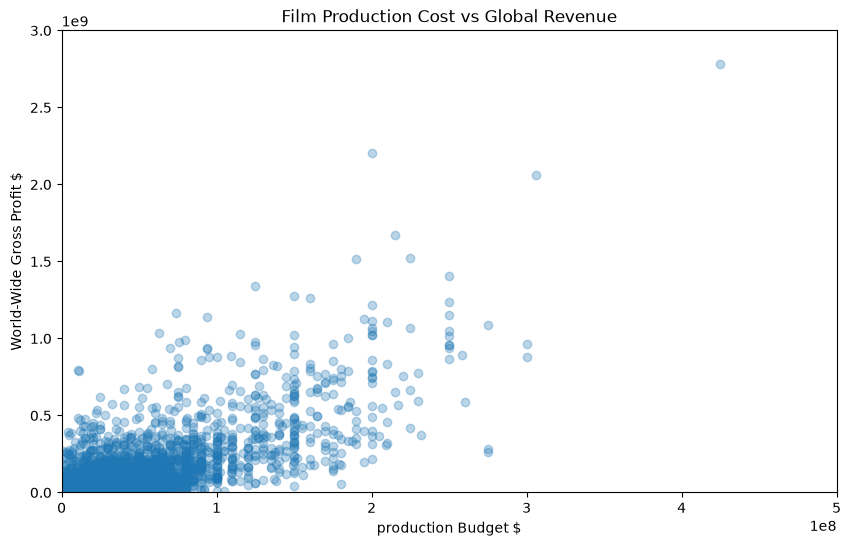

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.30)
plt.title('Film Production Cost vs Global Revenue')
plt.xlabel('production Budget $')
plt.ylabel('World-Wide Gross Profit $')
plt.ylim(0, 3e9)
plt.xlim(0, 5e8)
plt.show()


In [13]:
# hθ(x) = θ₀ + θ₁·x     (y = mx + c)
regression = skl.linear_model.LinearRegression()
regression.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[3.11]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['production_budget_usd']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-7236192.73]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
coefficient = regression.coef_
intercept = regression.intercept_
print("coefficient: ", coefficient, " intercept: ", intercept, " ")

coefficient:  [[3.11150918]]  intercept:  [-7236192.72913963]  


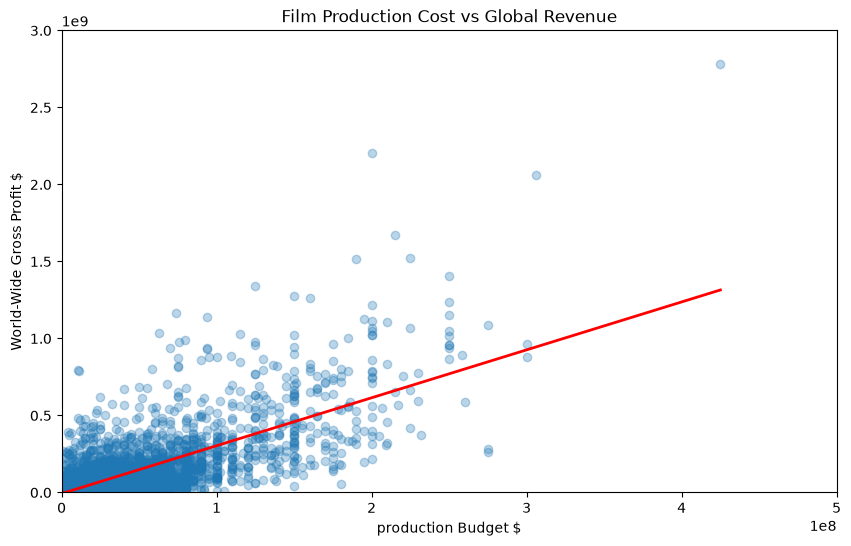

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.30)
plt.plot(x, regression.predict(x), color='red', linewidth=2)
plt.title('Film Production Cost vs Global Revenue')
plt.xlabel('production Budget $')
plt.ylabel('World-Wide Gross Profit $')
plt.ylim(0, 3e9)
plt.xlim(0, 5e8)
plt.show()

Revenue Prediction

In [16]:
budget = 5e6
prediction = intercept + (coefficient * budget)
prediction

array([[8321353.18554101]])

R-Square

In [17]:
regression.score(x, y)  # Amount of variation in film revenue that is explained by the film budget

0.5496485356985727